In [ ]:
import pandas as pd

######## Primero subimos el archivo 
archivo = 'ai4i2020.csv' 
df = pd.read_csv(archivo)

######### Y tomamos una muestra de los datos para verlos
print("Vista previa de los datos")
display(df.head())

######### Imprimimos la ficha tecnica del dataset
print("\nInformación del dataset")
print(f"Fuente: UCI Machine Learning Repository")
print(f"Tamaño (Filas, Columnas): {df.shape}")
print("\nTipos de Variables:")
print(df.dtypes)

######### Verificamos el balance de clases
conteo = df['Machine failure'].value_counts()
print("\nDistribución de fallas")
print(f"Máquinas OK (0): {conteo[0]}")
print(f"Máquinas con Falla (1): {conteo[1]}")

Vista previa de los datos


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



Información del dataset
Fuente: UCI Machine Learning Repository
Tamaño (Filas, Columnas): (10000, 14)

Tipos de Variables:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Distribución de fallas
Máquinas OK (0): 9661
Máquinas con Falla (1): 339


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
######## Elimina las columnas que no son relevantes para el modelo a
df_clean = df.drop(columns=['UDI', 'Product ID'])

######## Las variables categoricas se convierten en variables dummy
df_clean = pd.get_dummies(df_clean, columns=['Type'], drop_first=True)

######## Separamos las variables independientes y dependientes
X = df_clean.drop(columns=['Machine failure'])
y = df_clean['Machine failure']

######### Dividimos los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y) ####### Estratificamos por el desbalance de clases

######### Estandarizamos los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Ajustamos el modelo en el conjunto de entrenamiento
X_test_scaled = scaler.transform(X_test)       # Solo transformamos la sección de conjunto de prueba


In [ ]:
######## Implementar Soft SVM con Kernel RBF
###### C=1.0: Es el parámetro de regularización (Margen vs Errores permitidos)
###### class_weight='balanced': Obliga al modelo a darle más importancia a las máquinas 
####### en el cual se presentan las fallas (1)

svm_model = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42)

######## Entrenar el modelo
svm_model.fit(X_train_scaled, y_train)

######### Realizar predicciones
y_pred = svm_model.predict(X_test_scaled)

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



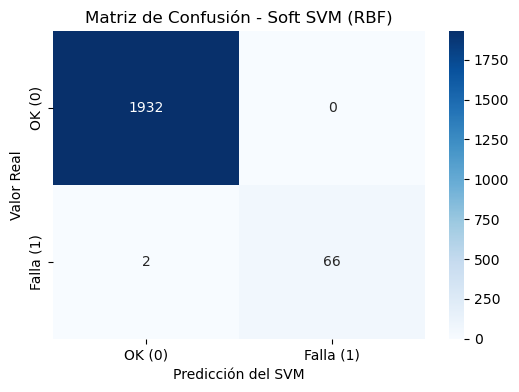

In [ ]:
######### Evaluar el modelo (NO usar solo Accuracy)
print("REPORTE DE CLASIFICACIÓN")
print(classification_report(y_test, y_pred))

######### Graficar la Matriz de Confusión para el documento
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['OK (0)', 'Falla (1)'], 
            yticklabels=['OK (0)', 'Falla (1)'])

plt.xlabel('Predicción del SVM')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Soft SVM (RBF)')
plt.show()